In [8]:
import sys
sys.path.insert(0, "../data")

from data_loading import load_train_test_split

X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)
print("features:", len(feature_cols))

train: (8644, 60) (8644,)
test:  (2162, 60) (2162,)
features: 60


In [9]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [10]:
def evaluate_svm(model_name, model, X_train, X_test, y_train, y_test):
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    print(model_name)
    print("Accuracy:", accuracy)
    print("F1:", f1)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Training Time:", train_time)
    print("Prediction Time:", pred_time)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Training Time": train_time,
        "Prediction Time": pred_time,
        "Predictions": y_pred,
        "Best Estimator": model
    }

In [12]:
# Baseline SVM
param_grid = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01]
}

baseline_grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

baseline_result = evaluate_svm(
    "SVM Baseline",
    baseline_grid,
    X_train,
    X_test,
    y_train,
    y_test
)

print("Best params:", baseline_grid.best_params_)

SVM Baseline
Accuracy: 0.17668825161887142
F1: 0.10482070511471582
Precision: 0.13326888446517837
Recall: 0.17668825161887142
Training Time: 891.8555490970612
Prediction Time: 0.8059988021850586

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        55
           1       0.00      0.00      0.00        77
           2       0.00      0.00      0.00        86
           3       0.17      0.66      0.27       356
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00         4
           6       0.00      0.00      0.00        35
           7       0.00      0.00      0.00         5
           8       0.00      0.00      0.00       130
           9       0.15      0.34      0.21       289
          10       0.00      0.00      0.00        44
          11       0.00      0.00      0.00        88
          12       0.00      0.00      0.00        66
          13       0.00 

In [13]:
# Balanced SVM
balanced_grid = GridSearchCV(
    SVC(class_weight="balanced"),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

balanced_result = evaluate_svm(
    "SVM Balanced",
    balanced_grid,
    X_train,
    X_test,
    y_train,
    y_test
)

print("Best params:", balanced_grid.best_params_)

SVM Balanced
Accuracy: 0.09944495837187789
F1: 0.1136047548345874
Precision: 0.19677539096398125
Recall: 0.09944495837187789
Training Time: 425.9429271221161
Prediction Time: 0.8111658096313477

Classification Report:
              precision    recall  f1-score   support

           0       0.08      0.11      0.09        55
           1       0.07      0.10      0.08        77
           2       0.08      0.10      0.09        86
           3       0.31      0.14      0.19       356
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00         4
           6       0.06      0.14      0.08        35
           7       0.00      0.00      0.00         5
           8       0.07      0.03      0.04       130
           9       0.19      0.18      0.19       289
          10       0.04      0.11      0.06        44
          11       0.16      0.14      0.15        88
          12       0.11      0.17      0.13        66
          13       0.07  

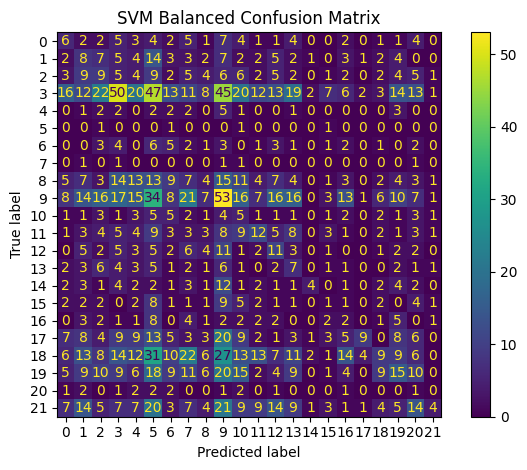

In [15]:
best_result = baseline_result if baseline_result["F1"] >= balanced_result["F1"] else balanced_result

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_result["Predictions"]
)

plt.title(best_result["Model"] + " Confusion Matrix")
plt.tight_layout()
plt.show()